# TravelTide – Explorative Datenanalyse

## Hintergrund und Ziel

In diesem Notebook wird die zuvor aufbereitete und auf Kundenebene
aggregierte Datengrundlage explorativ untersucht.

Ziel ist es, die demografischen Merkmale sowie das Such-, Buchungs-,
Stornierungs-, Rabatt- und Ausgabeverhalten der Kunden zu verstehen.
Dabei werden Verteilungen, Ausreißer und Zusammenhänge zwischen den
Merkmalen analysiert.

Die Ergebnisse bilden die Grundlage für die Auswahl geeigneter Variablen
zur Kundensegmentierung und für die spätere Zuordnung personalisierter
Loyalty-Programm-Benefits.

## 1. Datenimport und Ladeprüfung

In [2]:
# Bibliotheken importieren
 
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

In [3]:
# Aufbereitete Kundendaten laden

processed_path = Path("../data/processed")

customer_features = pd.read_csv(
    processed_path / "customer_features.csv"
)

print("Zeilen:", customer_features.shape[0])
print("Spalten:", customer_features.shape[1])

display(customer_features.head())

Zeilen: 5752
Spalten: 71


,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,age,customer_tenure_days,customer_tenure_months,session_count,mean_session_duration_minutes,median_session_duration_minutes,total_page_clicks,mean_page_clicks,low_click_session_rate,booking_session_count,flight_booking_session_count,hotel_booking_session_count,package_booking_session_count,cancellation_count,flight_discount_offer_count,hotel_discount_offer_count,mean_flight_discount_amount,mean_hotel_discount_amount,discounted_flight_booking_count,discounted_hotel_booking_count,booking_session_rate,cancellation_session_rate,package_booking_rate,flight_discount_conversion_rate,hotel_discount_conversion_rate,flight_booking_count,total_flight_spend_before_discount_usd,mean_flight_booking_value_before_discount_usd,total_seats,mean_seats,mean_fare_per_seat_usd,total_checked_bags,mean_checked_bags,return_flight_rate,cancelled_flight_count,weighted_fare_per_seat_usd,hotel_booking_count,total_hotel_spend_usd,mean_hotel_spend_usd,total_hotel_nights,mean_hotel_nights,total_rooms,mean_rooms,mean_hotel_price_per_room_usd,median_hotel_price_per_room_usd,unique_hotel_brands,unique_hotel_cities,extended_stay_booking_count,extended_stay_booking_share,cancelled_hotel_count,preferred_hotel_segment,preferred_hotel_city,hotel_price_tier_share_Low price,hotel_price_tier_share_Medium price,hotel_price_tier_share_High price,hotel_price_tier_share_Very high price,has_flight_booking,has_hotel_booking,has_travel_booking,total_cancelled_bookings
0,23557,1958-12-08,F,True,False,usa,new york,LGA,40.78,-73.87,2021-07-22,64,736,24.18,8,1.28,1.16,82,10.25,0.00,2,0,2,0,0,0,2,NaN,0.17,0,1,0.25,0.00,0.00,NaN,0.50,0.00,0.00,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,2.00,"3,802.00","1,901.00",20.00,10.00,3.00,1.50,177.00,177.00,2.00,2.00,1.00,0.50,0.00,Economy,Calgary,0.50,0.00,0.00,0.50,False,True,True,0.00
1,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.30,-94.71,2022-02-07,51,536,17.61,8,1.13,0.62,73,9.12,0.00,2,2,2,2,0,0,1,NaN,0.10,0,0,0.25,0.00,1.00,NaN,0.00,2.00,864.09,432.05,3.00,1.50,276.25,1.00,0.50,1.00,0.00,288.03,2.00,230.00,115.00,2.00,1.00,3.00,1.50,90.00,90.00,2.00,2.00,0.00,0.00,0.00,Luxury,Jacksonville,0.50,0.50,0.00,0.00,True,True,True,0.00
2,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.14,-122.48,2022-02-17,50,526,17.28,8,2.04,2.43,131,16.38,0.00,2,1,2,1,0,2,0,0.07,NaN,0,0,0.25,0.00,0.50,0.00,NaN,1.00,189.91,189.91,1.00,1.00,189.91,0.00,0.00,1.00,0.00,189.91,2.00,"2,199.00","1,099.50",8.00,4.00,3.00,1.50,198.50,198.50,2.00,2.00,0.00,0.00,0.00,Luxury,Edmonton,0.00,0.50,0.00,0.50,True,True,True,0.00
3,101961,1980-09-14,F,True,False,usa,boston,BOS,42.36,-71.00,2022-02-17,42,526,17.28,8,1.96,2.22,126,15.75,0.12,5,5,5,5,0,2,1,0.15,0.10,1,0,0.62,0.00,1.00,0.50,0.00,5.00,"1,242.66",248.53,5.00,1.00,248.53,2.00,0.40,1.00,0.00,248.53,5.00,"2,429.00",485.80,19.00,3.80,5.00,1.00,136.00,132.00,5.00,5.00,1.00,0.20,0.00,Luxury,Charlotte,0.20,0.40,0.40,0.00,True,True,True,0.00
4,106907,1978-11-17,F,True,True,usa,miami,TNT,25.86,-80.90,2022-02-24,44,519,17.05,8,12.65,2.39,240,30.00,0.00,1,1,1,1,1,1,1,NaN,NaN,0,0,0.12,0.12,1.00,0.00,0.00,1.00,"13,902.06","13,902.06",6.00,6.00,"2,317.01",5.00,5.00,1.00,1.00,"2,317.01",1.00,"4,257.00","4,257.00",11.00,11.00,3.00,3.00,129.00,129.00,1.00,1.00,0.00,0.00,1.00,Luxury,Durban,0.00,1.00,0.00,0.00,True,True,True,2.00


In [4]:
# Datumsangaben wiederherstellen

date_columns = [
    "birthdate",
    "sign_up_date"
]

for column in date_columns:
    if column in customer_features.columns:
        customer_features[column] = pd.to_datetime(
            customer_features[column],
            errors="coerce"
        )

In [5]:
# Ladeprüfung

print(
    "Eindeutige Nutzer:",
    customer_features["user_id"].nunique()
)

print(
    "Doppelte Nutzer:",
    customer_features["user_id"].duplicated().sum()
)

print(
    "Fehlende user_id:",
    customer_features["user_id"].isna().sum()
)

customer_features.info()

Eindeutige Nutzer: 5752
Doppelte Nutzer: 0
Fehlende user_id: 0
<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 71 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   user_id                                        5752 non-null   int64         
 1   birthdate                                      5752 non-null   datetime64[us]
 2   gender                                         5752 non-null   str           
 3   married                                        5752 non-null   bool          
 4   has_children                                   5752 non-null   bool          
 5   home_country                                   5752 non-null   str           
 6   home_city                                      5752 non-null   str           
 7   home_airport                                   5752 non-null   str           
 8   home_a

## 2. Demografische Struktur der Kunden

Zunächst wird die demografische Zusammensetzung der Kundenkohorte untersucht.
Betrachtet werden insbesondere Alter, Geschlecht, Herkunftsland, Familienstand,
Kinderstatus und bisherige Kundendauer.

Die demografischen Merkmale helfen später bei der Beschreibung der
Kundensegmente. Sie werden jedoch nicht automatisch alle für die Bildung der
Segmente verwendet.

In [6]:
# Numerische Übersicht

demographic_numeric_columns = [
    "age",
    "customer_tenure_days",
    "customer_tenure_months"
]

display(
    customer_features[
        demographic_numeric_columns
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
age,"5,752.00",41.91,11.18,18.00,35.00,42.00,49.00,88.00
customer_tenure_days,"5,752.00",188.90,35.38,71.00,173.00,190.00,201.00,736.00
customer_tenure_months,"5,752.00",6.21,1.16,2.33,5.68,6.24,6.60,24.18


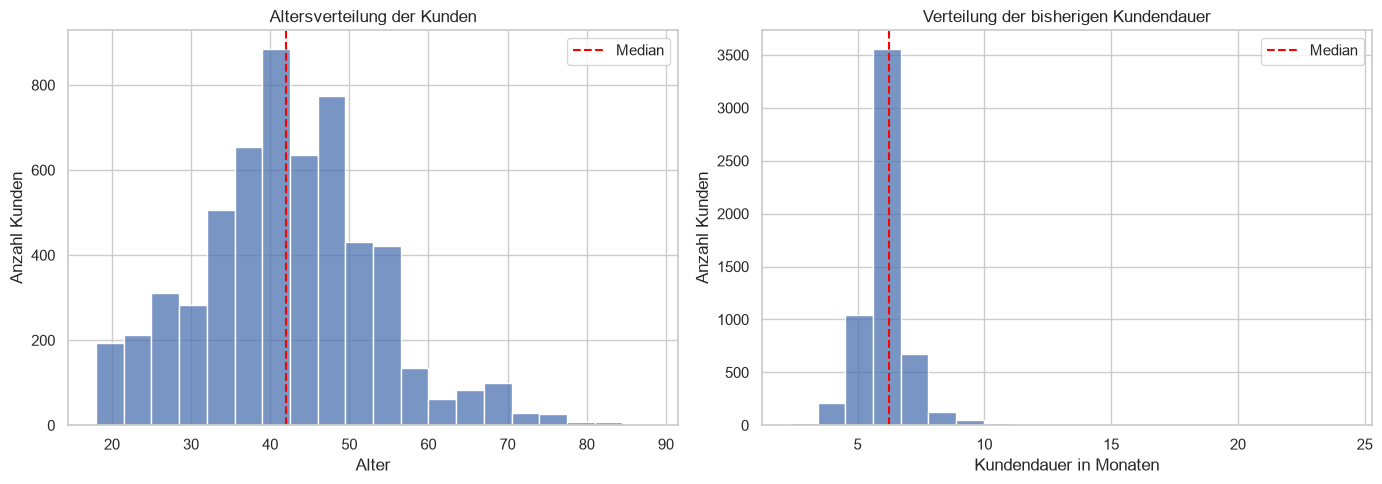

In [13]:
# Alter und Kundendauer visualisieren

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=customer_features,
    x="age",
    bins=20,
    ax=axes[0]
)

axes[0].axvline(
    customer_features["age"].median(),
    color="red",
    linestyle="--",
    label="Median"
)

axes[0].set_title("Altersverteilung der Kunden")
axes[0].set_xlabel("Alter")
axes[0].set_ylabel("Anzahl Kunden")
axes[0].legend()

sns.histplot(
    data=customer_features,
    x="customer_tenure_months",
    bins=20,
    ax=axes[1]
)

axes[1].axvline(
    customer_features["customer_tenure_months"].median(),
    color="red",
    linestyle="--",
    label="Median"
)

axes[1].set_title("Verteilung der bisherigen Kundendauer")
axes[1].set_xlabel("Kundendauer in Monaten")
axes[1].set_ylabel("Anzahl Kunden")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Altersgruppen ergänzen und anzeigen

customer_features["age_group"] = pd.cut(
    customer_features["age"],
    bins=[
        18,
        25,
        35,
        45,
        55,
        65,
        np.inf
    ],
    labels=[
        "18–24",
        "25–34",
        "35–44",
        "45–54",
        "55–64",
        "65+"
    ],
    right=False
)

age_group_overview = (
    customer_features["age_group"]
    .value_counts(sort=False)
    .rename_axis("age_group")
    .reset_index(name="customer_count")
)

age_group_overview["customer_share_percent"] = (
    age_group_overview["customer_count"]
    / len(customer_features)
    * 100
).round(2)

display(age_group_overview)

,age_group,customer_count,customer_share_percent
0,18–24,405,7.04
1,25–34,936,16.27
2,35–44,2140,37.20
3,45–54,1657,28.81
4,55–64,381,6.62
5,65+,233,4.05


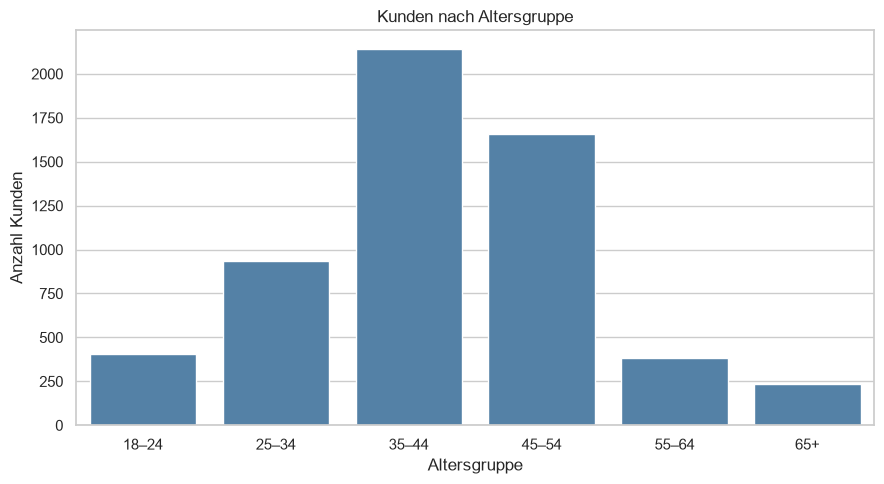

In [12]:
# Altersgruppen visualisieren

plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_group_overview,
    x="age_group",
    y="customer_count",
    color="steelblue"
)

plt.title("Kunden nach Altersgruppe")
plt.xlabel("Altersgruppe")
plt.ylabel("Anzahl Kunden")

plt.tight_layout()
plt.show()

In [10]:
# Kategorische Merkmale untersuchen

categorical_demographic_columns = [
    "gender",
    "home_country",
    "married",
    "has_children"
]

for column in categorical_demographic_columns:
    overview = (
        customer_features[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="customer_count")
    )

    overview["customer_share_percent"] = (
        overview["customer_count"]
        / len(customer_features)
        * 100
    ).round(2)

    print(f"\nVerteilung von {column}:")
    display(overview)


Verteilung von gender:


,gender,customer_count,customer_share_percent
0,F,5071,88.16
1,M,671,11.67
2,O,10,0.17



Verteilung von home_country:


,home_country,customer_count,customer_share_percent
0,usa,4789,83.26
1,canada,963,16.74



Verteilung von married:


,married,customer_count,customer_share_percent
0,False,3111,54.09
1,True,2641,45.91



Verteilung von has_children:


,has_children,customer_count,customer_share_percent
0,False,3858,67.07
1,True,1894,32.93


,characteristic,customer_count,customer_share_percent
0,Married,2641,45.91
1,Has children,1894,32.93


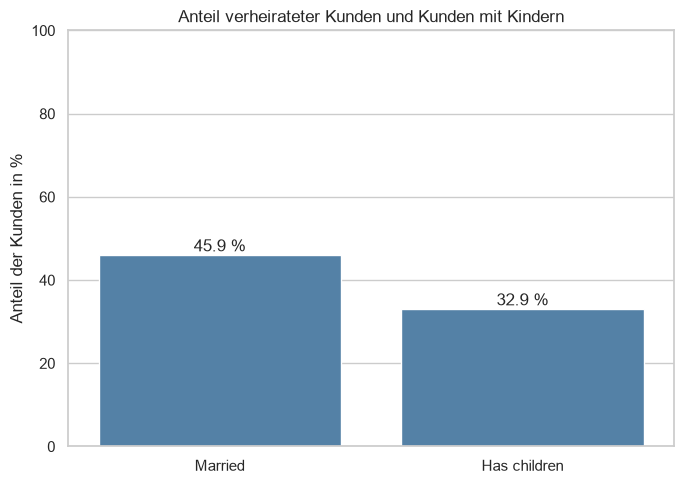

In [16]:
# Familienstruktur kompakt darstellen

family_overview = pd.DataFrame({
    "characteristic": [
        "Married",
        "Has children"
    ],
    "customer_count": [
        customer_features["married"].sum(),
        customer_features["has_children"].sum()
    ]
})

family_overview["customer_share_percent"] = (
    family_overview["customer_count"]
    / len(customer_features)
    * 100
).round(2)

display(family_overview)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=family_overview,
    x="characteristic",
    y="customer_share_percent",
    color="steelblue"
)

plt.title("Anteil verheirateter Kunden und Kunden mit Kindern")
plt.xlabel("")
plt.ylabel("Anteil der Kunden in %")
plt.ylim(0, 100)

for index, value in enumerate(
    family_overview["customer_share_percent"]
):
    plt.text(
        index,
        value + 1,
        f"{value:.1f} %",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Zwischenergebnis: Demografische Kundenstruktur

Das Durchschnittsalter der 5.752 Kunden beträgt rund 42 Jahre. Etwa zwei
Drittel der Kunden sind zwischen 35 und 54 Jahre alt, wobei die Altersgruppe
von 35 bis 44 Jahren den größten Anteil bildet.

Die Kundenkohorte ist demografisch deutlich unausgewogen: Rund 88 % der
Kunden sind weiblich und etwa 83 % leben in den USA. Knapp 46 % sind
verheiratet und etwa ein Drittel hat Kinder.

Die typische Kundendauer liegt bei ungefähr sechs Monaten. Einzelne Kunden
sind jedoch bereits seit bis zu zwei Jahren registriert, wodurch eine
rechtsschiefe Verteilung entsteht.

Aufgrund der starken Ungleichverteilung sollten Geschlecht und Herkunftsland
nicht unkritisch zur Bildung der Kundensegmente verwendet werden. Diese
Merkmale eignen sich vor allem zur nachträglichen Beschreibung der anhand
des Kundenverhaltens gebildeten Segmente.

## 3. Session- und Suchverhalten

In diesem Abschnitt wird untersucht, wie häufig und intensiv die Kunden
TravelTide nutzen. Betrachtet werden die Anzahl der Sessions, die
durchschnittliche Sitzungsdauer, Seitenklicks, Sessions mit geringer
Interaktion sowie die Buchungsquote.

Die Merkmale beschreiben unterschiedliche Aspekte der Kundenaktivität und
können Hinweise auf Engagement, Suchintensität und Buchungsbereitschaft
geben.

In [17]:
# Statistische Übersicht

session_eda_columns = [
    "session_count",
    "mean_session_duration_minutes",
    "median_session_duration_minutes",
    "total_page_clicks",
    "mean_page_clicks",
    "low_click_session_rate",
    "booking_session_count",
    "booking_session_rate"
]

display(
    customer_features[
        session_eda_columns
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    ).T
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
session_count,"5,752.00",8.21,0.46,8.00,8.00,8.00,8.00,8.00,8.00,9.00,10.00,11.00
mean_session_duration_minutes,"5,752.00",3.12,4.00,0.53,0.85,1.12,1.57,1.95,2.46,16.11,18.51,35.63
median_session_duration_minutes,"5,752.00",1.71,0.68,0.38,0.56,0.75,1.19,1.66,2.17,2.79,3.42,11.53
total_page_clicks,"5,752.00",145.13,72.37,33.00,57.00,73.00,103.00,128.00,162.00,305.00,429.49,873.00
mean_page_clicks,"5,752.00",17.69,8.73,4.12,6.88,9.00,12.62,15.62,19.69,37.12,51.81,109.12
low_click_session_rate,"5,752.00",0.01,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.12,0.12,0.25
booking_session_count,"5,752.00",2.75,1.51,0.00,0.00,0.00,2.00,3.00,4.00,5.00,6.00,8.00
booking_session_rate,"5,752.00",0.34,0.18,0.00,0.00,0.00,0.22,0.38,0.50,0.62,0.75,1.00


,session_count,customer_count
0,8,4704
1,9,924
2,10,116
3,11,8


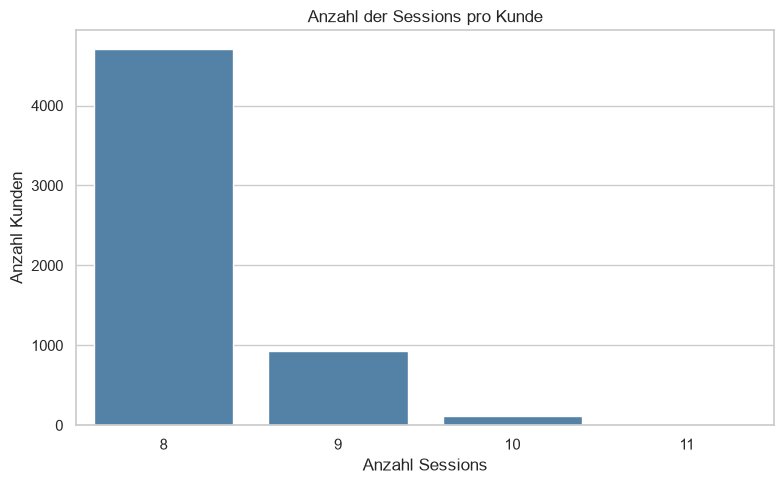

In [18]:
# Verteilung der Sessionanzahl

session_count_overview = (
    customer_features["session_count"]
    .value_counts()
    .sort_index()
    .rename_axis("session_count")
    .reset_index(name="customer_count")
)

display(session_count_overview)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=session_count_overview,
    x="session_count",
    y="customer_count",
    color="steelblue"
)

plt.title("Anzahl der Sessions pro Kunde")
plt.xlabel("Anzahl Sessions")
plt.ylabel("Anzahl Kunden")

plt.tight_layout()
plt.show()

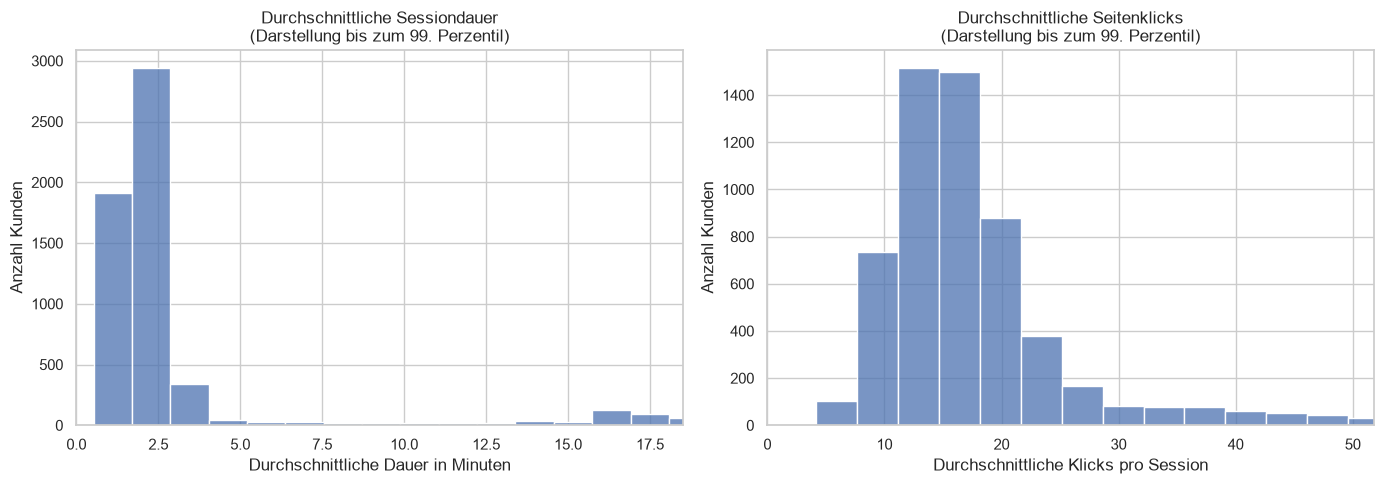

In [19]:
# Sessiondauer und Seitenklicks

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

duration_limit = customer_features[
    "mean_session_duration_minutes"
].quantile(0.99)

click_limit = customer_features[
    "mean_page_clicks"
].quantile(0.99)

sns.histplot(
    data=customer_features,
    x="mean_session_duration_minutes",
    bins=30,
    ax=axes[0]
)

axes[0].set_xlim(0, duration_limit)
axes[0].set_title(
    "Durchschnittliche Sessiondauer\n"
    "(Darstellung bis zum 99. Perzentil)"
)
axes[0].set_xlabel("Durchschnittliche Dauer in Minuten")
axes[0].set_ylabel("Anzahl Kunden")

sns.histplot(
    data=customer_features,
    x="mean_page_clicks",
    bins=30,
    ax=axes[1]
)

axes[1].set_xlim(0, click_limit)
axes[1].set_title(
    "Durchschnittliche Seitenklicks\n"
    "(Darstellung bis zum 99. Perzentil)"
)
axes[1].set_xlabel("Durchschnittliche Klicks pro Session")
axes[1].set_ylabel("Anzahl Kunden")

plt.tight_layout()
plt.show()

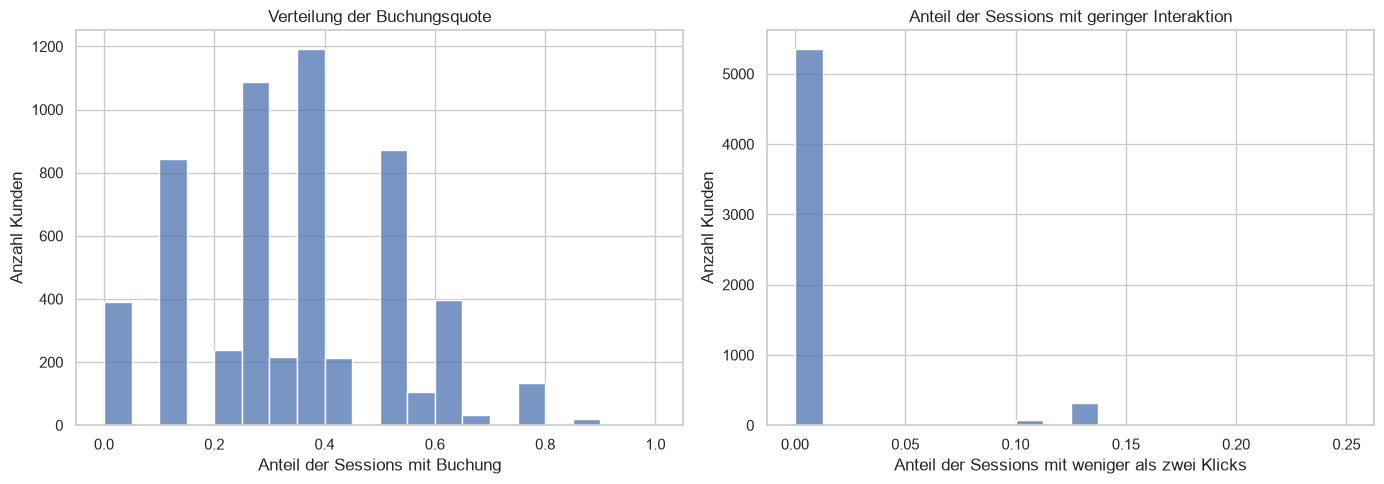

In [20]:
# Buchungsquote und geringe Interaktion

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=customer_features,
    x="booking_session_rate",
    bins=20,
    ax=axes[0]
)

axes[0].set_title("Verteilung der Buchungsquote")
axes[0].set_xlabel("Anteil der Sessions mit Buchung")
axes[0].set_ylabel("Anzahl Kunden")

sns.histplot(
    data=customer_features,
    x="low_click_session_rate",
    bins=20,
    ax=axes[1]
)

axes[1].set_title("Anteil der Sessions mit geringer Interaktion")
axes[1].set_xlabel("Anteil der Sessions mit weniger als zwei Klicks")
axes[1].set_ylabel("Anzahl Kunden")

plt.tight_layout()
plt.show()

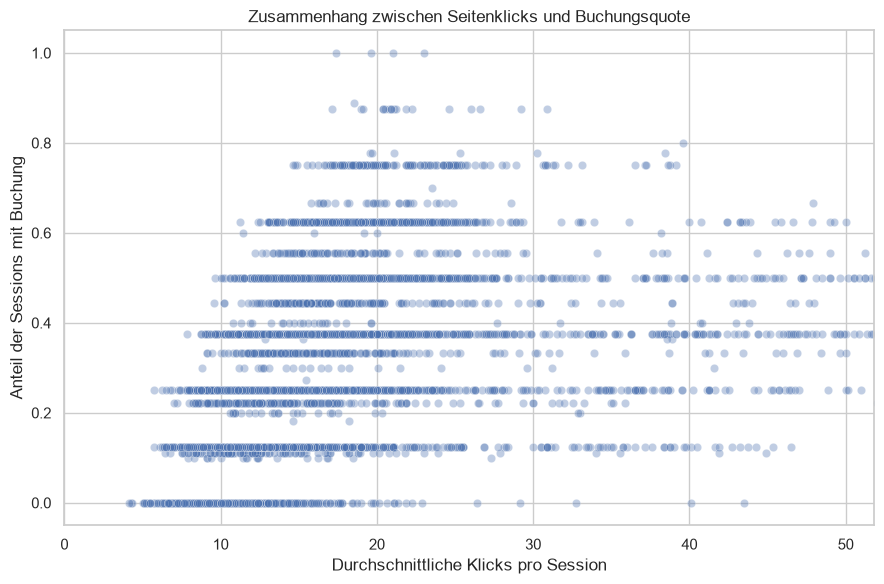

In [ ]:
# Darstellung des Zusammenhangs zwischen Suchintensität und Buchungsquote

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_features,
    x="mean_page_clicks",
    y="booking_session_rate",
    alpha=0.35
)

plt.xlim(
    0,
    customer_features["mean_page_clicks"].quantile(0.99)
)

plt.title(
    "Zusammenhang zwischen Seitenklicks und Buchungsquote"
)
plt.xlabel("Durchschnittliche Klicks pro Session")
plt.ylabel("Anteil der Sessions mit Buchung")

plt.tight_layout()
plt.show()

In [ ]:
# Berechnen der Korrelation zwischen Suchintensität und Buchungsquote.
 
session_booking_correlation = (
    customer_features[
        [
            "mean_page_clicks",
            "mean_session_duration_minutes",
            "low_click_session_rate",
            "booking_session_rate"
        ]
    ]
    .corr()
)

display(session_booking_correlation.round(3))

,mean_page_clicks,mean_session_duration_minutes,low_click_session_rate,booking_session_rate
mean_page_clicks,1.00,0.89,-0.07,0.33
mean_session_duration_minutes,0.89,1.00,-0.04,0.13
low_click_session_rate,-0.07,-0.04,1.00,-0.09
booking_session_rate,0.33,0.13,-0.09,1.00


### Zwischenergebnis: Session- und Suchverhalten

Die Anzahl der Sessions unterscheidet sich zwischen den Kunden nur gering.
Der Großteil besitzt genau acht Sessions, was unmittelbar aus der Definition
der Kundenkohorte resultiert. Die Sessionanzahl bietet daher voraussichtlich
nur wenig zusätzliche Information für die Kundensegmentierung.

Die typische Session ist relativ kurz. Bei der durchschnittlichen
Sessiondauer treten jedoch einzelne hohe Werte auf, wodurch die Verteilung
deutlich rechtsschief ist. Die mediane Sessiondauer stellt daher
möglicherweise ein robusteres Aktivitätsmerkmal dar.

Auch die durchschnittlichen Seitenklicks sind rechtsschief verteilt. Zwischen
Seitenklicks und durchschnittlicher Sessiondauer besteht mit 0,885 eine sehr
starke positive Korrelation. Beide Variablen messen somit weitgehend dieselbe
Form der Suchintensität und sollten später nicht unkritisch gemeinsam für die
Segmentierung verwendet werden.

Die durchschnittliche Buchungsquote beträgt etwa 34 % und zeigt im Gegensatz
zur Sessionanzahl eine deutliche Streuung zwischen den Kunden. Zwischen
Seitenklicks und Buchungsquote besteht lediglich ein schwach bis moderat
positiver Zusammenhang. Eine höhere Suchaktivität führt somit nicht
automatisch zu einer entsprechend hohen Buchungsquote.

Sessions mit weniger als zwei Klicks treten nur bei einem kleinen Teil der
Kunden auf. Das Merkmal eignet sich daher eher zur Beschreibung einzelner
auffälliger Kunden als zur zentralen Bildung der Kundensegmente.

## 4. Buchungs- und Stornierungsverhalten

Im folgenden Abschnitt wird untersucht, welche Reisebestandteile die Kunden
buchen und wie häufig kombinierte Flug- und Hotelbuchungen sowie
Stornierungen auftreten.

Diese Merkmale sind besonders relevant für die möglichen Rewards-Benefits
„keine Stornierungsgebühren“ und „kostenlose Hotelnacht bei gemeinsamer
Flugbuchung“.

In [ ]:
# Berechnung des Buchungstyps pro Kunde.

customer_features["booking_type"] = np.select(
    [
        (
            customer_features["has_flight_booking"]
            & customer_features["has_hotel_booking"]
        ),
        (
            customer_features["has_flight_booking"]
            & ~customer_features["has_hotel_booking"]
        ),
        (
            ~customer_features["has_flight_booking"]
            & customer_features["has_hotel_booking"]
        )
    ],
    [
        "Flight and hotel",
        "Flight only",
        "Hotel only"
    ],
    default="No travel booking"
)

booking_type_overview = (
    customer_features["booking_type"]
    .value_counts()
    .rename_axis("booking_type")
    .reset_index(name="customer_count")
)

booking_type_overview["customer_share_percent"] = (
    booking_type_overview["customer_count"]
    / len(customer_features)
    * 100
).round(2)

display(booking_type_overview)

,booking_type,customer_count,customer_share_percent
0,Flight and hotel,4935,85.80
1,No travel booking,390,6.78
2,Hotel only,305,5.30
3,Flight only,122,2.12


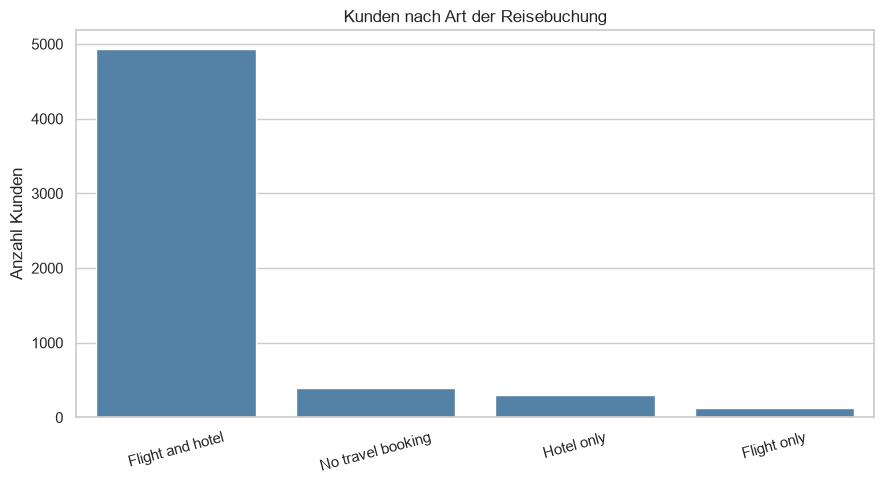

In [ ]:
# Darstellung des Buchungstyps pro Kunde.

plt.figure(figsize=(9, 5))

sns.barplot(
    data=booking_type_overview,
    x="booking_type",
    y="customer_count",
    color="steelblue"
)

plt.title("Kunden nach Art der Reisebuchung")
plt.xlabel("")
plt.ylabel("Anzahl Kunden")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
# Berechnung der Anzahl der Buchungen.
 
booking_count_columns = [
    "booking_session_count",
    "flight_booking_count",
    "hotel_booking_count",
    "package_booking_session_count"
]

display(
    customer_features[
        booking_count_columns
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
booking_session_count,"5,752.00",2.75,1.51,0.00,2.00,3.00,4.00,8.00
flight_booking_count,"5,752.00",2.36,1.50,0.00,1.00,2.00,3.00,8.00
hotel_booking_count,"5,752.00",2.45,1.45,0.00,1.00,2.00,3.00,8.00
package_booking_session_count,"5,752.00",2.05,1.43,0.00,1.00,2.00,3.00,8.00


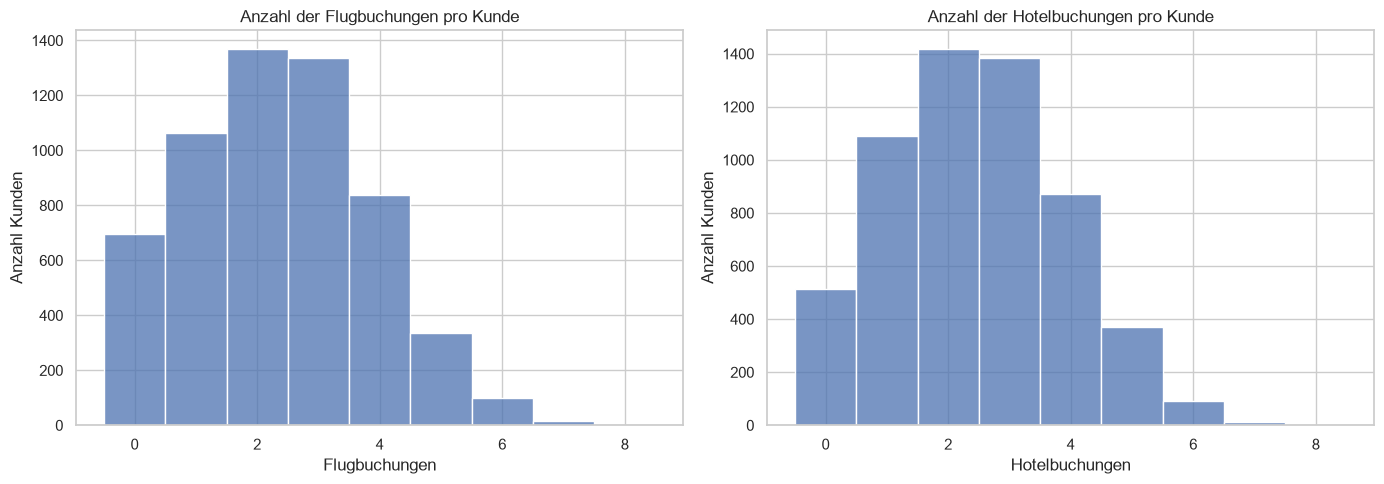

In [ ]:
# Darstellung der Anzahl der Buchungen pro Kunde.

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.histplot(
    data=customer_features,
    x="flight_booking_count",
    discrete=True,
    ax=axes[0]
)

axes[0].set_title("Anzahl der Flugbuchungen pro Kunde")
axes[0].set_xlabel("Flugbuchungen")
axes[0].set_ylabel("Anzahl Kunden")

sns.histplot(
    data=customer_features,
    x="hotel_booking_count",
    discrete=True,
    ax=axes[1]
)

axes[1].set_title("Anzahl der Hotelbuchungen pro Kunde")
axes[1].set_xlabel("Hotelbuchungen")
axes[1].set_ylabel("Anzahl Kunden")

plt.tight_layout()
plt.show()

In [ ]:
# Berechnung der Anteile der kombinierter Buchungen (Flug + Hotel) pro Kunde.

package_rate_summary = (
    customer_features["package_booking_rate"]
    .dropna()
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.95
        ]
    )
)

display(package_rate_summary)

count   5,360.00
mean        0.72
std         0.32
min         0.00
25%         0.50
50%         0.75
75%         1.00
95%         1.00
max         1.00
Name: package_booking_rate, dtype: float64

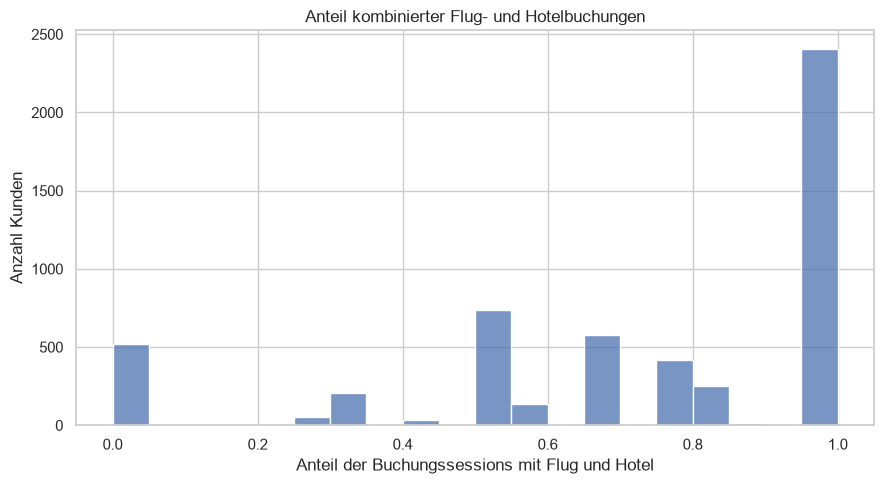

In [ ]:
# Darstellung der Anteile der kombinierter Buchungen (Flug + Hotel) pro Kunde.

plt.figure(figsize=(9, 5))

sns.histplot(
    data=customer_features[
        customer_features["package_booking_rate"].notna()
    ],
    x="package_booking_rate",
    bins=20
)

plt.title("Anteil kombinierter Flug- und Hotelbuchungen")
plt.xlabel("Anteil der Buchungssessions mit Flug und Hotel")
plt.ylabel("Anzahl Kunden")

plt.tight_layout()
plt.show()

In [ ]:
# Berechnung des Stornierungsverhaltens.

customer_features["has_cancellation"] = (
    customer_features["cancellation_count"] > 0
)

cancellation_overview = pd.DataFrame({
    "characteristic": [
        "No cancellation",
        "At least one cancellation"
    ],
    "customer_count": [
        (~customer_features["has_cancellation"]).sum(),
        customer_features["has_cancellation"].sum()
    ]
})

cancellation_overview["customer_share_percent"] = (
    cancellation_overview["customer_count"]
    / len(customer_features)
    * 100
).round(2)

display(cancellation_overview)

,characteristic,customer_count,customer_share_percent
0,No cancellation,5190,90.23
1,At least one cancellation,562,9.77


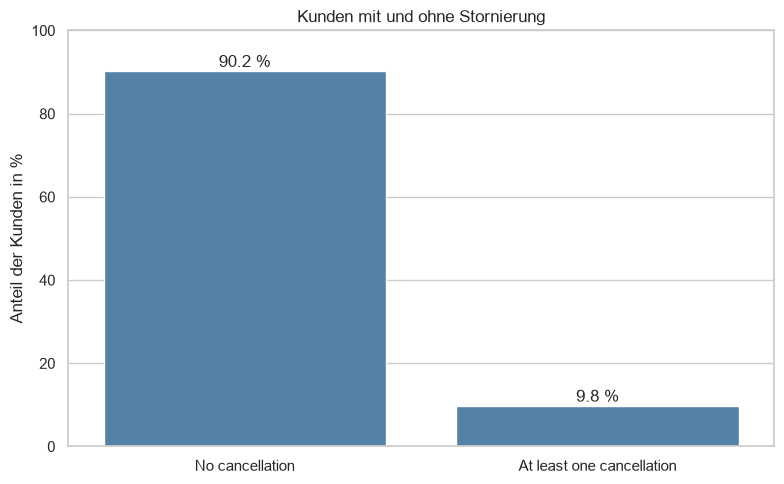

In [ ]:
# Darstellung des Stornierungsverhaltens.

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cancellation_overview,
    x="characteristic",
    y="customer_share_percent",
    color="steelblue"
)

plt.title("Kunden mit und ohne Stornierung")
plt.xlabel("")
plt.ylabel("Anteil der Kunden in %")
plt.ylim(0, 100)

for index, value in enumerate(
    cancellation_overview["customer_share_percent"]
):
    plt.text(
        index,
        value + 1,
        f"{value:.1f} %",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Grundsätzliche Berechnung der Stornierungsmetriken.
 
display(
    customer_features[
        [
            "cancellation_count",
            "cancellation_session_rate",
            "total_cancelled_bookings"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
cancellation_count,"5,752.00",0.10,0.31,0.00,0.00,0.00,0.00,2.00
cancellation_session_rate,"5,752.00",0.01,0.04,0.00,0.00,0.00,0.00,0.25
total_cancelled_bookings,"5,752.00",0.16,0.52,0.00,0.00,0.00,0.00,4.00
